[INFO] CUDA device: Tesla T4, capability=sm_75
[INFO] Config
{
  "data_root": "/kaggle/input/datasets/chonlanawawa/bloodclot-segement/bloodclot_seg/split_by_patient_task",
  "task": "hemorrhage",
  "output_dir": "/kaggle/working/outputs_unet_radimagenet_fixed",
  "use_25d": true,
  "in_channels": 3,
  "image_size": [
    256,
    256
  ],
  "img_divisor": 255.0,
  "positive_cases_only_train": true,
  "positive_cases_only_val": true,
  "positive_cases_only_test": true,
  "include_neighbor_slices": 2,
  "max_negative_ratio_train": 0.3,
  "max_negative_ratio_val": 0.5,
  "max_negative_ratio_test": 0.5,
  "seed": 42,
  "device": "cuda",
  "epochs": 40,
  "batch_size": 8,
  "num_workers": 2,
  "lr": 0.0001,
  "weight_decay": 0.0001,
  "grad_clip": 1.0,
  "amp": true,
  "dice_weight": 0.7,
  "bce_weight": 0.3,
  "fixed_train_val_threshold": 0.5,
  "threshold_candidates": [
    0.1,
    0.15000000000000002,
    0.20000000000000004,
    0.25000000000000006,
    0.30000000000000004,
    0.35000

100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


[DEBUG] model conv1 shape: (64, 3, 7, 7)
[INFO] Loading RadImageNet checkpoint from: /kaggle/input/datasets/chonlanawawa/radimagenet/RadImageNet_pytorch/ResNet50.pt
[INFO] RadImageNet encoder load done.
[INFO] Missing keys after partial load: 62
[INFO] Unexpected keys ignored: 0
[INFO] Matched encoder tensors loaded: 318
[INFO] Skipped encoder tensors: 0
[INFO] Example loaded keys: ['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.bn1.num_batches_tracked', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.0.bn2.num_batches_tracked', 'layer1.0.conv3.weight', 'layer1.0.bn3.weight']
[INFO] Start training
[INFO] Fixed train/val threshold during training: 0.50
[EPOCH 1] train_loss=0.776567 train_dice@0.50=0.186783 va

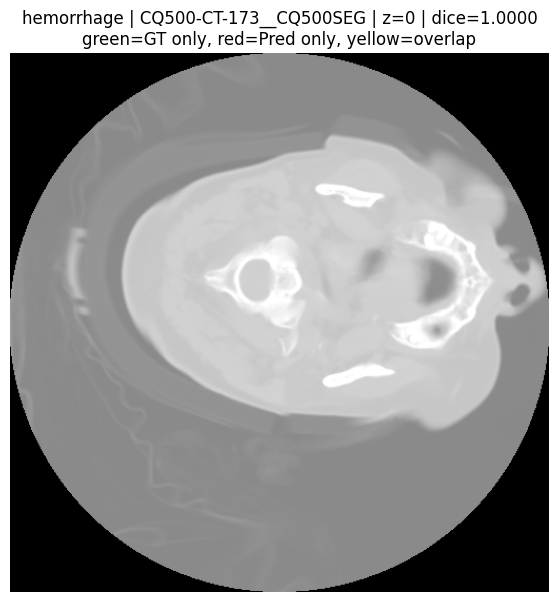

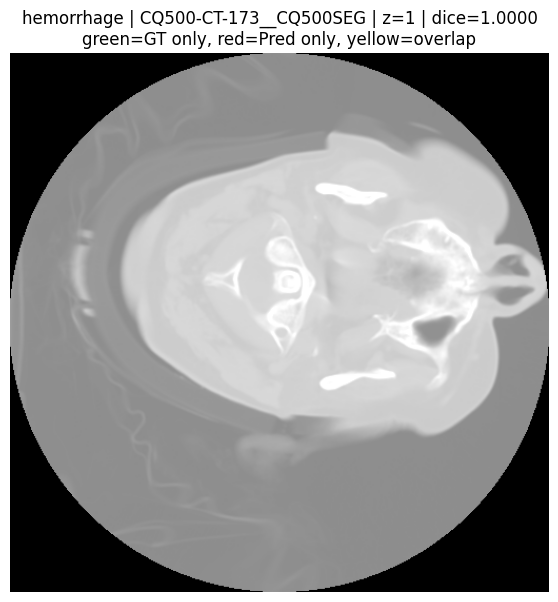

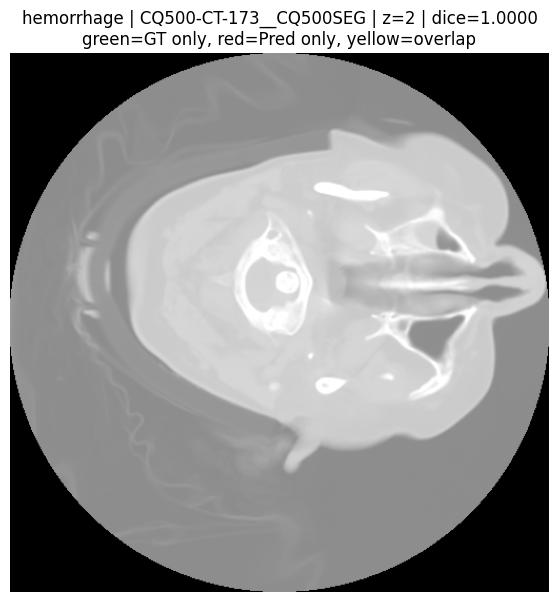

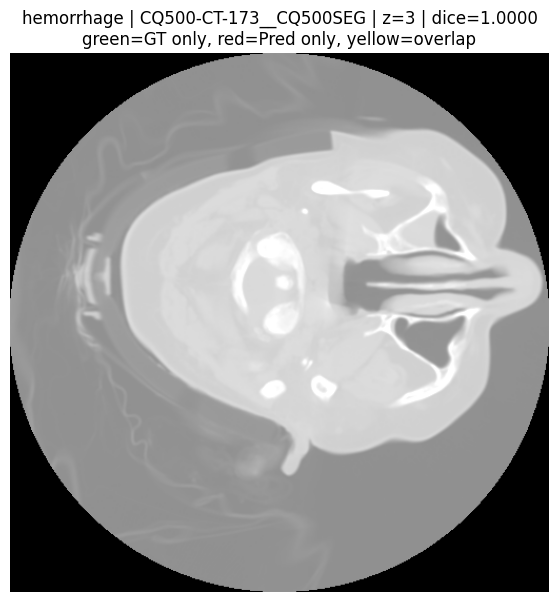

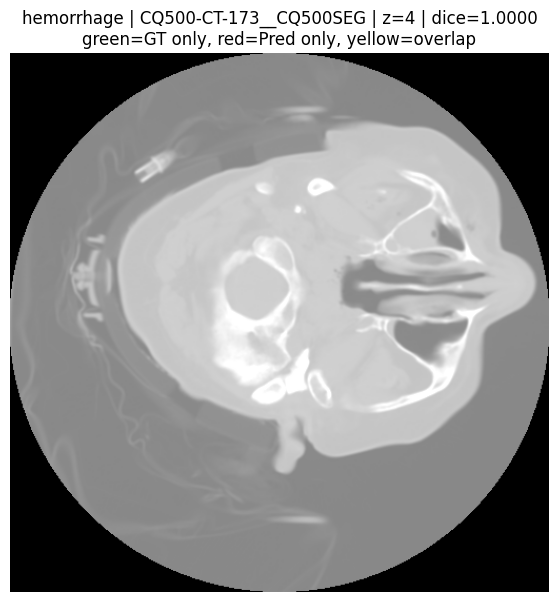

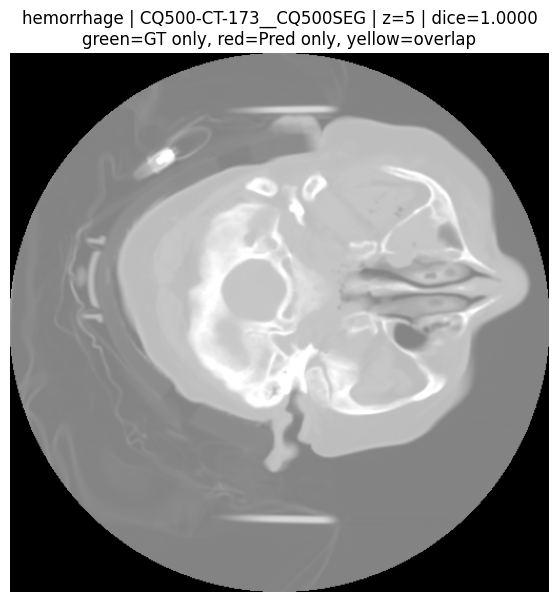

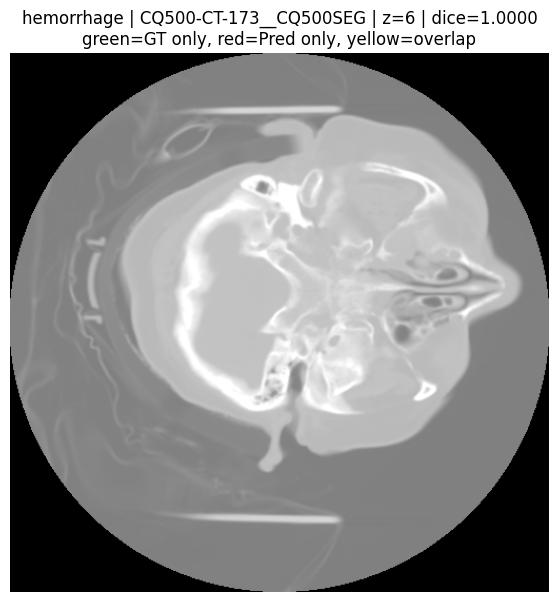

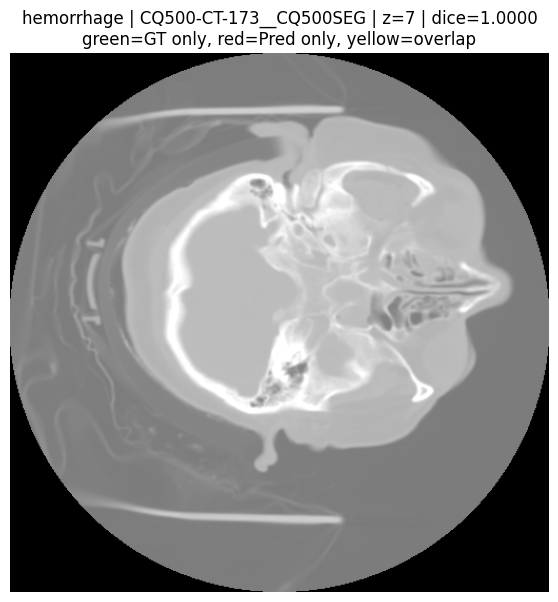

[INFO] Test overlays saved to: /kaggle/working/outputs_unet_radimagenet_fixed/hemorrhage_unet_resnet50_radimagenet_case_monitor/test_overlays_best
[INFO] Done


In [1]:
# =========================================================
# FIXED FULL TRAIN + VAL + TEST + OVERLAY PIPELINE
# - fixed RadImageNet key remap
# - fixed DataLoader collate crash
# - fixed train/val metric mismatch
# - fixed per-epoch threshold instability
# - fixed NaN/Inf loss/logit handling
# - best model now selected by val_case_mean
# =========================================================

import os
import json
import math
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
@dataclass
class Config:
    # dataset
    data_root: str = "/kaggle/input/datasets/chonlanawawa/bloodclot-segement/bloodclot_seg/split_by_patient_task"
    task: str = "hemorrhage"   # "hemorrhage" or "ischemia"
    output_dir: str = "/kaggle/working/outputs_unet_radimagenet_fixed"

    # input
    use_25d: bool = True
    in_channels: int = 3
    image_size: Tuple[int, int] = (256, 256)
    img_divisor: float = 255.0

    # sampling
    positive_cases_only_train: bool = True
    positive_cases_only_val: bool = True
    positive_cases_only_test: bool = True
    include_neighbor_slices: int = 2
    max_negative_ratio_train: float = 0.30
    max_negative_ratio_val: float = 0.50
    max_negative_ratio_test: float = 0.50

    # optimization
    seed: int = 42
    device: str = "cpu"
    epochs: int = 40
    batch_size: int = 8
    num_workers: int = 2
    lr: float = 1e-4
    weight_decay: float = 1e-4
    grad_clip: float = 1.0
    amp: bool = False

    # loss / metric
    dice_weight: float = 0.7
    bce_weight: float = 0.3
    fixed_train_val_threshold: float = 0.5
    threshold_candidates: Tuple[float, ...] = tuple(np.arange(0.10, 0.91, 0.05).tolist())
    threshold_tune_metric: str = "case_mean"  # "slice_mean", "global", "case_mean"

    # pretrained weights
    use_torchvision_imagenet_fallback: bool = True
    radimagenet_weights_path: Optional[str] = "/kaggle/input/datasets/chonlanawawa/radimagenet/RadImageNet_pytorch/ResNet50.pt"
    freeze_encoder_epochs: int = 0

    # scheduler / early stop
    patience: int = 12

    # postprocess
    use_postprocess: bool = True
    pp_min_area: int = 16
    pp_keep_top_k: Optional[int] = 2
    pp_do_open: bool = False
    pp_do_close: bool = True
    pp_structure_size: int = 3

    # save / vis
    save_test_predictions: bool = True
    save_test_overlays: bool = True
    show_inline_test_overlays: bool = True
    max_inline_overlays: int = 8


# =========================================================
# UTIL
# =========================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def save_json(obj, path: str):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def read_png_gray(path: str) -> np.ndarray:
    img = Image.open(path).convert("L")
    return np.array(img)


def resize_2d_np(x: np.ndarray, out_hw: Tuple[int, int], is_mask: bool = False) -> np.ndarray:
    xt = torch.from_numpy(x).float()
    if xt.ndim == 2:
        xt = xt.unsqueeze(0).unsqueeze(0)
    elif xt.ndim == 3:
        xt = xt.unsqueeze(0)
    else:
        raise ValueError(f"resize_2d_np expected 2D or 3D, got {x.shape}")

    mode = "nearest" if is_mask else "bilinear"
    if mode == "bilinear":
        xt = F.interpolate(xt, size=out_hw, mode=mode, align_corners=False)
    else:
        xt = F.interpolate(xt, size=out_hw, mode=mode)

    xt = xt.squeeze(0).cpu().numpy()
    return xt


def natural_sort_key(path_obj: Path):
    import re
    s = path_obj.stem
    parts = re.split(r"(\d+)", s)
    out = []
    for p in parts:
        out.append(int(p) if p.isdigit() else p)
    return out


def get_safe_device_and_amp():
    if not torch.cuda.is_available():
        print("[INFO] CUDA not available -> CPU")
        return "cpu", False

    try:
        name = torch.cuda.get_device_name(0)
        major, minor = torch.cuda.get_device_capability(0)
        print(f"[INFO] CUDA device: {name}, capability=sm_{major}{minor}")
        if major < 7:
            print("[WARN] GPU capability too old for current torch CUDA build -> CPU fallback")
            return "cpu", False
        return "cuda", True
    except Exception as e:
        print(f"[WARN] CUDA probe failed: {e} -> CPU fallback")
        return "cpu", False


def get_autocast_context(device: str, enabled: bool):
    return torch.amp.autocast(device_type="cuda", enabled=(enabled and device == "cuda"))


def get_grad_scaler(enabled: bool, device: str):
    if device == "cuda":
        return torch.amp.GradScaler("cuda", enabled=enabled)
    return torch.amp.GradScaler("cuda", enabled=False)


# =========================================================
# DATA DISCOVERY
# =========================================================
def discover_cases_png(split_root: Path) -> List[Dict]:
    cases = []
    if not split_root.exists():
        raise FileNotFoundError(f"Split folder not found: {split_root}")

    for case_dir in sorted([x for x in split_root.iterdir() if x.is_dir()]):
        img_dir = case_dir / "images" / "CT"
        mask_dir = case_dir / "masks" / "CT"

        if not img_dir.exists():
            continue

        image_files = sorted(img_dir.glob("*.png"), key=natural_sort_key)
        mask_files = sorted(mask_dir.glob("*.png"), key=natural_sort_key) if mask_dir.exists() else []

        if len(mask_files) == 0:
            continue

        if len(image_files) == 0 or len(image_files) != len(mask_files):
            print(f"[WARN] skip {case_dir.name}: image_count={len(image_files)} mask_count={len(mask_files)}")
            continue

        cases.append({
            "case_id": case_dir.name,
            "image_files": [str(p) for p in image_files],
            "mask_files": [str(p) for p in mask_files],
        })

    return cases


def preload_case_meta_png(cases: List[Dict]) -> List[Dict]:
    out = []
    for c in cases:
        try:
            pos_slices = []
            H, W = None, None
            for i, mp in enumerate(c["mask_files"]):
                m = read_png_gray(mp)
                if H is None:
                    H, W = m.shape
                if (m > 0).sum() > 0:
                    pos_slices.append(i)

            c2 = dict(c)
            c2["z"] = len(c["image_files"])
            c2["shape_zyx"] = (len(c["image_files"]), H, W)
            c2["positive_slices"] = pos_slices
            c2["is_positive_case"] = len(pos_slices) > 0
            out.append(c2)
        except Exception as e:
            print(f"[WARN] Failed meta preload for {c['case_id']}: {e}")
    return out


def build_slice_index(
    cases: List[Dict],
    positive_cases_only: bool,
    include_neighbor_slices: int,
    max_negative_ratio: float,
) -> List[Dict]:
    items = []

    for c in cases:
        if positive_cases_only and not c["is_positive_case"]:
            continue

        z_total = c["z"]
        pos = set(c["positive_slices"])

        selected = set()
        for z in pos:
            selected.add(z)
            for dz in range(-include_neighbor_slices, include_neighbor_slices + 1):
                zz = z + dz
                if 0 <= zz < z_total:
                    selected.add(zz)

        all_slices = set(range(z_total))
        neg = sorted(list(all_slices - selected))

        if len(neg) > 0 and max_negative_ratio > 0:
            target_neg = int(len(selected) * max_negative_ratio)
            target_neg = min(target_neg, len(neg))
            sampled_neg = random.sample(neg, target_neg) if target_neg > 0 else []
        else:
            sampled_neg = []

        final_slices = sorted(list(selected) + sampled_neg)

        if not c["is_positive_case"] and not positive_cases_only:
            final_slices = list(range(z_total))

        for z_idx in final_slices:
            items.append({
                "case_id": c["case_id"],
                "image_files": c["image_files"],
                "mask_files": c["mask_files"],
                "z_idx": int(z_idx),
            })

    return items


# =========================================================
# DATASET
# =========================================================
class BloodClotPNGDataset(Dataset):
    def __init__(
        self,
        items: List[Dict],
        image_size: Tuple[int, int],
        img_divisor: float = 255.0,
        use_25d: bool = True,
        train: bool = True,
    ):
        self.items = items
        self.image_size = image_size
        self.img_divisor = img_divisor
        self.use_25d = use_25d
        self.train = train

    def __len__(self):
        return len(self.items)

    def _read_img(self, path: str) -> np.ndarray:
        x = read_png_gray(path).astype(np.float32) / self.img_divisor
        return np.clip(x, 0.0, 1.0)

    def _read_mask(self, path: str) -> np.ndarray:
        m = read_png_gray(path)
        return (m > 0).astype(np.float32)

    def _get_slice_stack(self, image_files: List[str], z: int) -> np.ndarray:
        Z = len(image_files)

        def clamp_idx(idx: int) -> int:
            return max(0, min(Z - 1, idx))

        if self.use_25d:
            idxs = [clamp_idx(z - 1), clamp_idx(z), clamp_idx(z + 1)]
            x = np.stack([self._read_img(image_files[i]) for i in idxs], axis=0)
        else:
            x = self._read_img(image_files[z])[None, ...]
        return x.astype(np.float32)

    def _augment(self, x: np.ndarray, y: np.ndarray):
        if random.random() < 0.5:
            x = np.flip(x, axis=2).copy()
            y = np.flip(y, axis=2).copy()

        if random.random() < 0.15:
            x = np.flip(x, axis=1).copy()
            y = np.flip(y, axis=1).copy()

        if random.random() < 0.3:
            scale = 1.0 + random.uniform(-0.08, 0.08)
            shift = random.uniform(-0.05, 0.05)
            x = np.clip(x * scale + shift, 0.0, 1.0)

        if random.random() < 0.2:
            noise = np.random.normal(0, 0.01, size=x.shape).astype(np.float32)
            x = np.clip(x + noise, 0.0, 1.0)

        return x, y

    def __getitem__(self, idx):
        item = self.items[idx]
        z = item["z_idx"]

        x = self._get_slice_stack(item["image_files"], z)
        y = self._read_mask(item["mask_files"][z])[None, ...]

        x = resize_2d_np(x, self.image_size, is_mask=False)
        y = resize_2d_np(y, self.image_size, is_mask=True)

        if self.train:
            x, y = self._augment(x, y)

        return {
            "image": torch.from_numpy(x).float(),
            "mask": torch.from_numpy(y).float(),
            "case_id": item["case_id"],
            "z_idx": z,
        }


# =========================================================
# LOSS / METRIC
# =========================================================
class SoftDiceLoss(nn.Module):
    def __init__(self, eps: float = 1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        target = target.view(target.size(0), -1)

        inter = (probs * target).sum(dim=1)
        denom = probs.sum(dim=1) + target.sum(dim=1)
        dice = (2.0 * inter + self.eps) / (denom + self.eps)
        loss = 1.0 - dice
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1.0, neginf=1.0)
        return loss.mean()


class ComboLoss(nn.Module):
    def __init__(self, dice_weight: float = 0.7, bce_weight: float = 0.3):
        super().__init__()
        self.dice = SoftDiceLoss()
        self.bce = nn.BCEWithLogitsLoss()
        self.dw = dice_weight
        self.bw = bce_weight

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
        dice_loss = self.dice(logits, target)
        bce_loss = self.bce(logits, target)
        loss = self.dw * dice_loss + self.bw * bce_loss
        loss = torch.nan_to_num(loss, nan=1.0, posinf=1.0, neginf=1.0)
        return loss


def batch_dice_from_logits(
    logits: torch.Tensor,
    target: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-8,
) -> float:
    logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
    probs = torch.sigmoid(logits)
    pred = (probs >= threshold).float()

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    inter = (pred * target).sum(dim=1)
    denom = pred.sum(dim=1) + target.sum(dim=1)
    dice = (2.0 * inter + eps) / (denom + eps)

    both_empty = (pred.sum(dim=1) == 0) & (target.sum(dim=1) == 0)
    dice = torch.where(both_empty, torch.ones_like(dice), dice)
    dice = torch.nan_to_num(dice, nan=0.0, posinf=0.0, neginf=0.0)

    return float(dice.mean().item())


def dice_binary_np(pred: np.ndarray, target: np.ndarray, eps: float = 1e-8) -> float:
    pred = (pred > 0).astype(np.uint8)
    target = (target > 0).astype(np.uint8)

    pred_sum = pred.sum()
    target_sum = target.sum()

    if pred_sum == 0 and target_sum == 0:
        return 1.0

    inter = (pred & target).sum()
    return float((2.0 * inter + eps) / (pred_sum + target_sum + eps))


def global_dice_from_counts(total_inter: float, total_pred: float, total_gt: float, eps: float = 1e-8) -> float:
    if total_pred == 0 and total_gt == 0:
        return 1.0
    return float((2.0 * total_inter + eps) / (total_pred + total_gt + eps))


# =========================================================
# POSTPROCESS
# =========================================================
def postprocess_binary_mask(
    mask_2d: np.ndarray,
    min_area: int = 16,
    keep_top_k: Optional[int] = 2,
    do_open: bool = False,
    do_close: bool = True,
    structure_size: int = 3,
) -> np.ndarray:
    mask = (mask_2d > 0).astype(np.uint8)
    structure = np.ones((structure_size, structure_size), dtype=np.uint8)

    if do_open:
        mask = ndimage.binary_opening(mask, structure=structure).astype(np.uint8)

    if do_close:
        mask = ndimage.binary_closing(mask, structure=structure).astype(np.uint8)

    labeled, num = ndimage.label(mask)
    if num == 0:
        return mask.astype(np.uint8)

    comp_sizes = ndimage.sum(mask, labeled, index=np.arange(1, num + 1))
    comp_sizes = np.asarray(comp_sizes)

    keep_labels = []
    for i, s in enumerate(comp_sizes, start=1):
        if s >= min_area:
            keep_labels.append((i, s))

    if len(keep_labels) == 0:
        return np.zeros_like(mask, dtype=np.uint8)

    keep_labels = sorted(keep_labels, key=lambda x: x[1], reverse=True)
    if keep_top_k is not None and keep_top_k > 0:
        keep_labels = keep_labels[:keep_top_k]

    keep_ids = set(x[0] for x in keep_labels)
    out = np.isin(labeled, list(keep_ids)).astype(np.uint8)
    return out


# =========================================================
# MODEL
# =========================================================
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.conv = ConvBNReLU(in_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


def adapt_first_conv(conv: nn.Conv2d, in_channels: int) -> nn.Conv2d:
    new_conv = nn.Conv2d(
        in_channels,
        conv.out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        bias=(conv.bias is not None),
    )

    with torch.no_grad():
        if in_channels == conv.in_channels:
            new_conv.weight.copy_(conv.weight)
        elif in_channels == 1:
            new_conv.weight.copy_(conv.weight.mean(dim=1, keepdim=True))
        elif in_channels > 3:
            new_conv.weight[:, :3].copy_(conv.weight)
            for c in range(3, in_channels):
                new_conv.weight[:, c:c+1].copy_(conv.weight.mean(dim=1, keepdim=True))
        else:
            new_conv.weight[:, :in_channels].copy_(conv.weight[:, :in_channels])

        if conv.bias is not None and new_conv.bias is not None:
            new_conv.bias.copy_(conv.bias)

    return new_conv


def extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["state_dict", "model_state_dict", "model", "net", "weights"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
        return ckpt
    return ckpt


def clean_resnet_state_dict(sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    cleaned = {}
    for k, v in sd.items():
        nk = str(k)
        for prefix in ["module.", "model.", "encoder.", "backbone.", "resnet."]:
            if nk.startswith(prefix):
                nk = nk[len(prefix):]
        cleaned[nk] = v
    return cleaned


def remap_radimagenet_resnet50_keys(sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    remapped = {}

    for k, v in sd.items():
        nk = k

        if nk == "0.weight":
            nk = "conv1.weight"
        elif nk.startswith("1."):
            nk = "bn1." + nk[2:]
        elif nk.startswith("4."):
            nk = "layer1." + nk[2:]
        elif nk.startswith("5."):
            nk = "layer2." + nk[2:]
        elif nk.startswith("6."):
            nk = "layer3." + nk[2:]
        elif nk.startswith("7."):
            nk = "layer4." + nk[2:]

        remapped[nk] = v

    return remapped


def build_resnet50_encoder(in_channels: int, use_torchvision_imagenet_fallback: bool = True):
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if use_torchvision_imagenet_fallback else None
    backbone = models.resnet50(weights=weights)
    if in_channels != 3:
        backbone.conv1 = adapt_first_conv(backbone.conv1, in_channels)
    return backbone


class UNetResNet50(nn.Module):
    def __init__(self, in_channels: int = 3, use_torchvision_imagenet_fallback: bool = True):
        super().__init__()
        backbone = build_resnet50_encoder(
            in_channels=in_channels,
            use_torchvision_imagenet_fallback=use_torchvision_imagenet_fallback,
        )

        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.center = ConvBNReLU(2048, 512)
        self.up4 = UpBlock(512, 1024, 256)
        self.up3 = UpBlock(256, 512, 128)
        self.up2 = UpBlock(128, 256, 64)
        self.up1 = UpBlock(64, 64, 32)

        self.stem_refine = ConvBNReLU(32, 32)
        self.seg_head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))
        x1 = self.maxpool(x0)
        x1 = self.layer1(x1)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)

        x = self.center(x4)
        x = self.up4(x, x3)
        x = self.up3(x, x2)
        x = self.up2(x, x1)
        x = self.up1(x, x0)
        x = self.stem_refine(x)
        x = self.seg_head(x)
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = torch.nan_to_num(x, nan=0.0, posinf=20.0, neginf=-20.0)
        return x

    def encoder_parameters(self):
        return (
            list(self.conv1.parameters()) +
            list(self.bn1.parameters()) +
            list(self.layer1.parameters()) +
            list(self.layer2.parameters()) +
            list(self.layer3.parameters()) +
            list(self.layer4.parameters())
        )


def maybe_load_radimagenet_weights(model: UNetResNet50, ckpt_path: Optional[str]):
    if ckpt_path is None:
        print("[INFO] No RadImageNet checkpoint path provided; keeping current encoder init.")
        return

    ckpt_path = str(ckpt_path)
    if not os.path.exists(ckpt_path):
        print(f"[WARN] RadImageNet checkpoint not found: {ckpt_path}")
        return

    print(f"[INFO] Loading RadImageNet checkpoint from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")

    sd_raw = extract_state_dict(ckpt)
    if not isinstance(sd_raw, dict):
        print(f"[WARN] Unexpected checkpoint type: {type(sd_raw)}")
        print("[WARN] Keeping current encoder init.")
        return

    sd = clean_resnet_state_dict(sd_raw)
    sd = remap_radimagenet_resnet50_keys(sd)

    model_sd = model.state_dict()
    encoder_keys = [
        k for k in model_sd.keys()
        if (
            k.startswith("conv1.")
            or k.startswith("bn1.")
            or k.startswith("layer1.")
            or k.startswith("layer2.")
            or k.startswith("layer3.")
            or k.startswith("layer4.")
        )
    ]

    loadable = {}
    skipped = []
    found_but_shape_mismatch = []

    for k in encoder_keys:
        if k not in sd:
            skipped.append(k)
            continue

        v = sd[k]

        if model_sd[k].shape == v.shape:
            loadable[k] = v
            continue

        if k == "conv1.weight" and v.ndim == 4 and model_sd[k].shape[0] == v.shape[0]:
            if model_sd[k].shape[1] == 1 and v.shape[1] == 3:
                loadable[k] = v.mean(dim=1, keepdim=True)
                continue

            if model_sd[k].shape[1] > 3 and v.shape[1] == 3:
                new_v = torch.zeros_like(model_sd[k])
                new_v[:, :3] = v
                mean_ch = v.mean(dim=1, keepdim=True)
                for c in range(3, new_v.shape[1]):
                    new_v[:, c:c+1] = mean_ch
                loadable[k] = new_v
                continue

            if model_sd[k].shape[1] == 3 and v.shape[1] == 1:
                loadable[k] = v.repeat(1, 3, 1, 1)
                continue

        found_but_shape_mismatch.append((k, tuple(v.shape), tuple(model_sd[k].shape)))
        skipped.append(k)

    if len(loadable) == 0:
        print("[WARN] Matched encoder tensors loaded: 0")
        print("[WARN] Sample raw checkpoint keys:", list(sd_raw.keys())[:20])
        print("[WARN] Sample remapped checkpoint keys:", list(sd.keys())[:20])
        print("[WARN] Keeping current encoder init (torchvision ImageNet if enabled).")
        return

    msg = model.load_state_dict(loadable, strict=False)

    print("[INFO] RadImageNet encoder load done.")
    print("[INFO] Missing keys after partial load:", len(msg.missing_keys))
    print("[INFO] Unexpected keys ignored:", len(msg.unexpected_keys))
    print("[INFO] Matched encoder tensors loaded:", len(loadable))
    print("[INFO] Skipped encoder tensors:", len(skipped))

    if len(found_but_shape_mismatch) > 0:
        print("[INFO] Example shape mismatches:")
        for item in found_but_shape_mismatch[:10]:
            print("   ", item)

    print("[INFO] Example loaded keys:", list(loadable.keys())[:20])


# =========================================================
# VIS HELPERS
# =========================================================
def get_center_slice_gray(image_files: List[str], z: int, img_divisor: float) -> np.ndarray:
    gray = read_png_gray(image_files[z]).astype(np.float32) / img_divisor
    return np.clip(gray, 0.0, 1.0)


def make_overlap_overlay(gray_01: np.ndarray, gt: np.ndarray, pred: np.ndarray, alpha: float = 0.45):
    base = (np.clip(gray_01, 0.0, 1.0) * 255).astype(np.uint8)
    rgb = np.stack([base, base, base], axis=-1).astype(np.float32)

    gt = gt.astype(bool)
    pred = pred.astype(bool)

    gt_only = gt & (~pred)
    pred_only = pred & (~gt)
    overlap = gt & pred

    out = rgb.copy()

    green = np.array([0, 255, 0], dtype=np.float32)
    red = np.array([255, 0, 0], dtype=np.float32)
    yellow = np.array([255, 255, 0], dtype=np.float32)

    out[gt_only] = (1 - alpha) * out[gt_only] + alpha * green
    out[pred_only] = (1 - alpha) * out[pred_only] + alpha * red
    out[overlap] = (1 - alpha) * out[overlap] + alpha * yellow

    return np.clip(out, 0, 255).astype(np.uint8)


# =========================================================
# TRAIN / VALID / EVAL
# =========================================================
def train_one_epoch(model, loader, optimizer, scaler, criterion, device, grad_clip=1.0, amp=True, threshold=0.5):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    n_samples = 0
    skipped_batches = 0

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with get_autocast_context(device, amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
            loss = criterion(logits, y)

        if not torch.isfinite(loss):
            skipped_batches += 1
            print("[WARN][train] non-finite loss batch skipped")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        dice = batch_dice_from_logits(logits.detach(), y, threshold=threshold)

        running_loss += float(loss.item()) * bs
        running_dice += float(dice) * bs
        n_samples += bs

    if skipped_batches > 0:
        print(f"[INFO][train] skipped non-finite batches: {skipped_batches}")

    return running_loss / max(n_samples, 1), running_dice / max(n_samples, 1)


@torch.no_grad()
def evaluate_loader_at_fixed_threshold(model, loader, criterion, device, threshold=0.5, cfg: Optional[Config] = None, amp=True):
    model.eval()

    running_loss = 0.0
    n_samples = 0
    skipped_batches = 0

    all_rows = []
    case_stats = {}

    total_inter = 0.0
    total_pred = 0.0
    total_gt = 0.0

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)
        case_ids = batch["case_id"]
        z_idxs = batch["z_idx"]

        with get_autocast_context(device, amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)
            loss = criterion(logits, y)

        if not torch.isfinite(loss):
            skipped_batches += 1
            print("[WARN][val/test] non-finite loss batch skipped")
            continue

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        target = y.detach().cpu().numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_samples += bs

        for i in range(bs):
            pred_i = (probs[i, 0] >= threshold).astype(np.uint8)
            gt_i = (target[i, 0] > 0.5).astype(np.uint8)

            if cfg is not None and cfg.use_postprocess:
                pred_i = postprocess_binary_mask(
                    pred_i,
                    min_area=cfg.pp_min_area,
                    keep_top_k=cfg.pp_keep_top_k,
                    do_open=cfg.pp_do_open,
                    do_close=cfg.pp_do_close,
                    structure_size=cfg.pp_structure_size,
                )

            dice_i = dice_binary_np(pred_i, gt_i)
            inter_i = float((pred_i & gt_i).sum())
            pred_fg = float(pred_i.sum())
            gt_fg = float(gt_i.sum())

            total_inter += inter_i
            total_pred += pred_fg
            total_gt += gt_fg

            cid = case_ids[i]
            if cid not in case_stats:
                case_stats[cid] = {"inter": 0.0, "pred": 0.0, "gt": 0.0}

            case_stats[cid]["inter"] += inter_i
            case_stats[cid]["pred"] += pred_fg
            case_stats[cid]["gt"] += gt_fg

            all_rows.append({
                "case_id": cid,
                "z_idx": int(z_idxs[i]),
                "dice": float(dice_i),
                "pred_fg": int(pred_fg),
                "gt_fg": int(gt_fg),
            })

    if skipped_batches > 0:
        print(f"[INFO][val/test] skipped non-finite batches: {skipped_batches}")

    mean_loss = running_loss / max(n_samples, 1)
    mean_slice_dice = float(np.mean([r["dice"] for r in all_rows])) if len(all_rows) > 0 else 0.0
    global_dice = global_dice_from_counts(total_inter, total_pred, total_gt)

    case_rows = []
    for cid, s in case_stats.items():
        case_rows.append({
            "case_id": cid,
            "case_dice": global_dice_from_counts(s["inter"], s["pred"], s["gt"]),
            "pred_fg": int(s["pred"]),
            "gt_fg": int(s["gt"]),
        })
    case_rows = sorted(case_rows, key=lambda x: x["case_id"])

    case_mean = float(np.mean([r["case_dice"] for r in case_rows])) if len(case_rows) > 0 else 0.0
    case_std = float(np.std([r["case_dice"] for r in case_rows])) if len(case_rows) > 0 else 0.0

    return {
        "loss": float(mean_loss),
        "slice_mean_dice": float(mean_slice_dice),
        "global_dice": float(global_dice),
        "case_mean_dice": float(case_mean),
        "case_std_dice": float(case_std),
        "slice_rows": all_rows,
        "case_rows": case_rows,
    }


@torch.no_grad()
def tune_threshold_on_loader(model, loader, criterion, device, cfg: Config, amp=True):
    results = []

    for th in cfg.threshold_candidates:
        th = float(th)
        metrics = evaluate_loader_at_fixed_threshold(
            model=model,
            loader=loader,
            criterion=criterion,
            device=device,
            threshold=th,
            cfg=cfg,
            amp=amp,
        )

        results.append({
            "threshold": th,
            "loss": metrics["loss"],
            "slice_mean_dice": metrics["slice_mean_dice"],
            "global_dice": metrics["global_dice"],
            "case_mean_dice": metrics["case_mean_dice"],
            "case_std_dice": metrics["case_std_dice"],
        })

    key_name = {
        "slice_mean": "slice_mean_dice",
        "global": "global_dice",
        "case_mean": "case_mean_dice",
    }[cfg.threshold_tune_metric]

    best_row = max(results, key=lambda r: r[key_name])
    return float(best_row["threshold"]), results


@torch.no_grad()
def test_slicewise(model, loader, device, threshold=0.5, cfg: Optional[Config] = None, amp=True, save_dir=None):
    model.eval()
    rows = []

    if save_dir is not None:
        ensure_dir(save_dir)

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["mask"].to(device, non_blocking=True)
        case_ids = batch["case_id"]
        z_idxs = batch["z_idx"]

        with get_autocast_context(device, amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.detach().cpu().numpy()

        bs = x.size(0)
        for i in range(bs):
            pred_i = (probs[i, 0] >= threshold).astype(np.uint8)
            gt_i = (y_np[i, 0] > 0.5).astype(np.uint8)

            if cfg is not None and cfg.use_postprocess:
                pred_i = postprocess_binary_mask(
                    pred_i,
                    min_area=cfg.pp_min_area,
                    keep_top_k=cfg.pp_keep_top_k,
                    do_open=cfg.pp_do_open,
                    do_close=cfg.pp_do_close,
                    structure_size=cfg.pp_structure_size,
                )

            dice_i = dice_binary_np(pred_i, gt_i)

            row = {
                "case_id": case_ids[i],
                "z_idx": int(z_idxs[i]),
                "dice": float(dice_i),
                "gt_fg": int(gt_i.sum()),
                "pred_fg": int(pred_i.sum()),
            }
            rows.append(row)

            if save_dir is not None:
                case_dir = Path(save_dir) / case_ids[i]
                ensure_dir(str(case_dir))
                pred_np = (pred_i * 255).astype(np.uint8)
                Image.fromarray(pred_np).save(case_dir / f"{int(z_idxs[i]):04d}.png")

    mean_dice = float(np.mean([r["dice"] for r in rows])) if len(rows) > 0 else 0.0
    return mean_dice, rows


@torch.no_grad()
def save_test_overlays(
    model,
    loader,
    device,
    threshold: float,
    cfg: Config,
    save_root: str,
    item_lookup: Dict[Tuple[str, int], Dict],
):
    model.eval()
    ensure_dir(save_root)

    shown = 0

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        case_ids = batch["case_id"]
        z_idxs = batch["z_idx"]

        with get_autocast_context(device, cfg.amp):
            logits = model(x)
            logits = torch.nan_to_num(logits, nan=0.0, posinf=20.0, neginf=-20.0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()

        bs = x.size(0)
        for i in range(bs):
            case_id = case_ids[i]
            z = int(z_idxs[i])

            meta = item_lookup[(case_id, z)]
            image_files = meta["image_files"]
            mask_files = meta["mask_files"]

            gray = get_center_slice_gray(image_files, z, cfg.img_divisor)
            gt = (read_png_gray(mask_files[z]) > 0).astype(np.uint8)

            prob_i = probs[i, 0]
            prob_i = resize_2d_np(prob_i, gray.shape, is_mask=False)
            if prob_i.ndim == 3:
                prob_i = prob_i[0]

            pred = (prob_i >= threshold).astype(np.uint8)
            if cfg.use_postprocess:
                pred = postprocess_binary_mask(
                    pred,
                    min_area=cfg.pp_min_area,
                    keep_top_k=cfg.pp_keep_top_k,
                    do_open=cfg.pp_do_open,
                    do_close=cfg.pp_do_close,
                    structure_size=cfg.pp_structure_size,
                )

            dice = dice_binary_np(pred, gt)
            overlay = make_overlap_overlay(gray, gt, pred, alpha=0.45)

            case_dir = Path(save_root) / case_id
            ensure_dir(str(case_dir))
            out_path = case_dir / f"{z:04d}_dice_{dice:.4f}.png"
            Image.fromarray(overlay).save(out_path)

            if cfg.show_inline_test_overlays and shown < cfg.max_inline_overlays:
                plt.figure(figsize=(7, 7))
                plt.imshow(overlay)
                plt.title(
                    f"{cfg.task} | {case_id} | z={z} | dice={dice:.4f}\n"
                    f"green=GT only, red=Pred only, yellow=overlap"
                )
                plt.axis("off")
                plt.show()
                shown += 1


# =========================================================
# MAIN
# =========================================================
def main():
    cfg = Config()
    cfg.device, cfg.amp = get_safe_device_and_amp()

    if cfg.device == "cpu":
        cfg.batch_size = min(cfg.batch_size, 4)
        cfg.num_workers = min(cfg.num_workers, 2)

    set_seed(cfg.seed)

    run_name = f"{cfg.task}_unet_resnet50_radimagenet_case_monitor"
    out_dir = Path(cfg.output_dir) / run_name
    ensure_dir(str(out_dir))

    print("[INFO] Config")
    print(json.dumps(asdict(cfg), indent=2))

    train_root = Path(cfg.data_root) / cfg.task / "train"
    val_root = Path(cfg.data_root) / cfg.task / "val"
    test_root = Path(cfg.data_root) / cfg.task / "test"

    train_cases = preload_case_meta_png(discover_cases_png(train_root))
    val_cases = preload_case_meta_png(discover_cases_png(val_root))
    test_cases = preload_case_meta_png(discover_cases_png(test_root))

    print(f"[INFO] train labeled cases discovered: {len(train_cases)}")
    print(f"[INFO] val labeled cases discovered:   {len(val_cases)}")
    print(f"[INFO] test labeled cases discovered:  {len(test_cases)}")

    train_items = build_slice_index(
        train_cases,
        positive_cases_only=cfg.positive_cases_only_train,
        include_neighbor_slices=cfg.include_neighbor_slices,
        max_negative_ratio=cfg.max_negative_ratio_train,
    )
    val_items = build_slice_index(
        val_cases,
        positive_cases_only=cfg.positive_cases_only_val,
        include_neighbor_slices=cfg.include_neighbor_slices,
        max_negative_ratio=cfg.max_negative_ratio_val,
    )
    test_items = build_slice_index(
        test_cases,
        positive_cases_only=cfg.positive_cases_only_test,
        include_neighbor_slices=cfg.include_neighbor_slices,
        max_negative_ratio=cfg.max_negative_ratio_test,
    )

    print(f"[INFO] train slice items: {len(train_items)}")
    print(f"[INFO] val slice items:   {len(val_items)}")
    print(f"[INFO] test slice items:  {len(test_items)}")

    if len(train_items) == 0:
        raise RuntimeError("No training slice items found.")
    if len(val_items) == 0:
        raise RuntimeError("No validation slice items found.")
    if len(test_items) == 0:
        print("[WARN] No test slice items found. Final test will be skipped.")

    test_item_lookup = {}
    for it in test_items:
        test_item_lookup[(it["case_id"], int(it["z_idx"]))] = {
            "image_files": it["image_files"],
            "mask_files": it["mask_files"],
        }

    train_ds = BloodClotPNGDataset(
        train_items,
        image_size=cfg.image_size,
        img_divisor=cfg.img_divisor,
        use_25d=cfg.use_25d,
        train=True,
    )
    val_ds = BloodClotPNGDataset(
        val_items,
        image_size=cfg.image_size,
        img_divisor=cfg.img_divisor,
        use_25d=cfg.use_25d,
        train=False,
    )
    test_ds = BloodClotPNGDataset(
        test_items,
        image_size=cfg.image_size,
        img_divisor=cfg.img_divisor,
        use_25d=cfg.use_25d,
        train=False,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.device == "cuda"),
        drop_last=False,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.device == "cuda"),
        drop_last=False,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=(cfg.device == "cuda"),
        drop_last=False,
    )

    in_ch = cfg.in_channels if cfg.use_25d else 1
    model = UNetResNet50(
        in_channels=in_ch,
        use_torchvision_imagenet_fallback=cfg.use_torchvision_imagenet_fallback,
    )
    print("[DEBUG] model conv1 shape:", tuple(model.state_dict()["conv1.weight"].shape))
    maybe_load_radimagenet_weights(model, cfg.radimagenet_weights_path)
    model = model.to(cfg.device)

    if cfg.freeze_encoder_epochs > 0:
        for p in model.encoder_parameters():
            p.requires_grad = False
        print(f"[INFO] Encoder frozen for first {cfg.freeze_encoder_epochs} epoch(s)")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=4,
    )
    criterion = ComboLoss(
        dice_weight=cfg.dice_weight,
        bce_weight=cfg.bce_weight,
    )
    scaler = get_grad_scaler(enabled=cfg.amp, device=cfg.device)

    best_monitor = -1.0
    best_epoch = -1
    best_threshold = cfg.fixed_train_val_threshold
    no_improve = 0
    history = []

    best_ckpt_path = out_dir / "best_model.pt"
    history_path = out_dir / "history.json"
    val_threshold_tuning_path = out_dir / "val_threshold_tuning.json"

    print("[INFO] Start training")
    print(f"[INFO] Fixed train/val threshold during training: {cfg.fixed_train_val_threshold:.2f}")

    for epoch in range(1, cfg.epochs + 1):
        if cfg.freeze_encoder_epochs > 0 and epoch == cfg.freeze_encoder_epochs + 1:
            for p in model.encoder_parameters():
                p.requires_grad = True
            print("[INFO] Encoder unfrozen")

        train_loss, train_dice = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            criterion=criterion,
            device=cfg.device,
            grad_clip=cfg.grad_clip,
            amp=cfg.amp,
            threshold=cfg.fixed_train_val_threshold,
        )

        val_metrics = evaluate_loader_at_fixed_threshold(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=cfg.device,
            threshold=cfg.fixed_train_val_threshold,
            cfg=cfg,
            amp=cfg.amp,
        )

        monitor_metric = val_metrics["case_mean_dice"]
        scheduler.step(monitor_metric)

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "train_dice_fixed_th": float(train_dice),
            "val_loss_fixed_th": float(val_metrics["loss"]),
            "val_slice_dice_fixed_th": float(val_metrics["slice_mean_dice"]),
            "val_global_dice_fixed_th": float(val_metrics["global_dice"]),
            "val_case_mean_dice_fixed_th": float(val_metrics["case_mean_dice"]),
            "val_case_std_dice_fixed_th": float(val_metrics["case_std_dice"]),
            "monitor_metric": float(monitor_metric),
            "monitor_name": "val_case_mean_dice_fixed_th",
            "fixed_threshold": float(cfg.fixed_train_val_threshold),
            "lr": float(optimizer.param_groups[0]["lr"]),
        }
        history.append(row)
        save_json(history, str(history_path))

        print(
            f"[EPOCH {epoch}] "
            f"train_loss={train_loss:.6f} "
            f"train_dice@{cfg.fixed_train_val_threshold:.2f}={train_dice:.6f} "
            f"val_loss={val_metrics['loss']:.6f} "
            f"val_slice_dice={val_metrics['slice_mean_dice']:.6f} "
            f"val_global_dice={val_metrics['global_dice']:.6f} "
            f"val_case_mean={val_metrics['case_mean_dice']:.6f}±{val_metrics['case_std_dice']:.6f} "
            f"lr={row['lr']:.6e}"
        )

        if monitor_metric > best_monitor:
            best_monitor = monitor_metric
            best_epoch = epoch
            best_threshold = cfg.fixed_train_val_threshold
            no_improve = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "config": asdict(cfg),
                "best_epoch": best_epoch,
                "best_monitor": best_monitor,
                "best_threshold": best_threshold,
                "monitor_name": "val_case_mean_dice_fixed_th",
            }, str(best_ckpt_path))

            print(
                f"[INFO] New best saved: "
                f"epoch={best_epoch}, "
                f"val_case_mean={best_monitor:.6f}, "
                f"th={best_threshold:.2f}"
            )
        else:
            no_improve += 1
            print(f"[INFO] No improvement for {no_improve} epoch(s)")

        if no_improve >= cfg.patience:
            print("[INFO] Early stopping triggered")
            break

    print(
        f"[INFO] Best epoch={best_epoch}, "
        f"best_val_case_mean={best_monitor:.6f}, "
        f"training_threshold={best_threshold:.2f}"
    )

    if best_ckpt_path.exists():
        ckpt = torch.load(str(best_ckpt_path), map_location=cfg.device)
        model.load_state_dict(ckpt["model_state_dict"], strict=True)
        best_threshold = float(ckpt.get("best_threshold", best_threshold))
        print(f"[INFO] Best checkpoint loaded from {best_ckpt_path}")

    # tune threshold once on val AFTER training
    tuned_threshold, threshold_results = tune_threshold_on_loader(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
        cfg=cfg,
        amp=cfg.amp,
    )
    save_json(threshold_results, str(val_threshold_tuning_path))
    print(f"[INFO] Post-training tuned threshold on val: {tuned_threshold:.2f}")

    best_threshold = tuned_threshold

    # final val at tuned threshold
    final_val_metrics = evaluate_loader_at_fixed_threshold(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=cfg.device,
        threshold=best_threshold,
        cfg=cfg,
        amp=cfg.amp,
    )

    print(
        f"[FINAL VAL] "
        f"loss={final_val_metrics['loss']:.6f} "
        f"slice_dice={final_val_metrics['slice_mean_dice']:.6f} "
        f"global_dice={final_val_metrics['global_dice']:.6f} "
        f"case_mean={final_val_metrics['case_mean_dice']:.6f}"
    )

    save_json(final_val_metrics["case_rows"], str(out_dir / "val_case_metrics.json"))
    save_json(final_val_metrics["slice_rows"], str(out_dir / "val_slice_metrics.json"))

    # final test
    if len(test_items) > 0:
        pred_dir = out_dir / "test_preds_best"
        overlay_dir = out_dir / "test_overlays_best"

        test_mean_dice, test_rows = test_slicewise(
            model=model,
            loader=test_loader,
            device=cfg.device,
            threshold=best_threshold,
            cfg=cfg,
            amp=cfg.amp,
            save_dir=str(pred_dir) if cfg.save_test_predictions else None,
        )
        print(f"[FINAL TEST] slice_mean_dice={test_mean_dice:.6f}")
        save_json(test_rows, str(out_dir / "test_slice_metrics.json"))

        if cfg.save_test_overlays:
            save_test_overlays(
                model=model,
                loader=test_loader,
                device=cfg.device,
                threshold=best_threshold,
                cfg=cfg,
                save_root=str(overlay_dir),
                item_lookup=test_item_lookup,
            )
            print(f"[INFO] Test overlays saved to: {overlay_dir}")

    print("[INFO] Done")


if __name__ == "__main__":
    main()